# Step 6 — Integrated Multi-Factor Fire-Risk Feature Table (v2, audit-corrected)
### Combines Step 1 (fire label), Step 2 (NDVI), Step 3 (LST), Step 4 (FLDAS + 2001 land cover), Step 5a/5b (terrain & accessibility) and the 2001 LULC forest fraction into one aligned table

---
**Status (2026-09-25): this notebook builds the corrected "v2" feature table defined by the
end-to-end methodology audit of 2026-09-24/25.** The audit of record is
`results/FULL_METHODOLOGY_AUDIT.md` (project-root repository); this step's own audit summary is
`Integrated_Analysis/AUDIT_2026-09-25.md`. The audit's reference implementation of the same
table, built from independent recalculations, is `results/code/build_v2_table.py` →
`results/recalculated/FEATURE_TABLE_v2.parquet`. This notebook builds the **same** table from the
regenerated step outputs, and (Step 8b below) compares itself column by column against that
reference when it is available.

Every input is already on the **NDVI grid** (3641 x 3504, EPSG:4326, 1/120° ≈ 0.0083° / ~0.9 km pixels, set up in
Step 2; older text calls it "0.01 deg", which the audit corrected). The only raster this notebook reprojects itself is the 2001 LULC forest fraction:

| Step | Source | What this notebook reads (v2) |
|---|---|---|
| 1 | MODIS C6.1 forest-fire points, 2000-11-01 to 2022-12-15 | `F10_fire_count_Step1.tif` (containing-pixel rasterisation), checked against a re-rasterisation of Step 1's CSV |
| 2 | MOD13A3 NDVI | QA mean, June climatology, Seasonal-Kendall τ, Sen slope, CVSI(k\*), LISA cluster |
| 3 | MOD11A2 LST Day / Night / DTR | 2001–2020 climatological level + Seasonal-Kendall τ |
| 4 | FLDAS Noah (7 variables) + ESA-CCI 22-class land cover | 2001–2020 climatological level + Seasonal-Kendall τ; **2001** class fractions |
| 5a | SRTMGL3 terrain | elevation, slope, aspect (encoded as sin/cos) |
| 5b | OSM 2022 accessibility | distance to roads / railways / waterways |
| – | ESA-CCI/C3S LULC 300 m, **2001** | forest fraction (13 LCCS forest codes, area average), **built and reprojected here** |

**Outputs** (`Integrated_Analysis/Integrated_Outputs/`):
1. **`Integrated_FireRisk_Pixels.parquet`**: one row per analysis pixel (inside the India
   state-boundary mask and with finite v2 NDVI mean), **ordered row-major by grid index**
   (`row*W + col`). Columns: `lon, lat, grid_index, fire_count, fire_ever` + 55 features.
   The row order matters: Step 7 rebuilds the audit's random 65/15/20 split from it.
2. **`FEATURE_LIST_v2.json`**: the ordered feature names, the source file of each feature, and the
   population and label definitions.
3. **`Integrated_FireRisk_Stack.tif`**: 55 bands, one per feature (band description = column
   name), NaN outside the analysis population.
4. `Integrated_Monthly_TimeSeries.csv` plus correlation and distribution plots (diagnostics only).

**Label:** `fire_ever = fire_count > 0`, pooled over the whole study period. `fire_count` is the
number of Step 1 forest-fire points whose coordinates fall **inside** the pixel footprint
(`floor` on pixel edges). The v1 label used a round-on-edges rule that shifted 74.9% of points
by half a pixel; that is fixed upstream in Step 2's F10 and checked again here.

**Primary evaluation population:** forest pixels (`forest_frac_baseline > 0`, about 1.20 M
pixels, prevalence about 22%). Across all pixels (prevalence about 6.45%), forest fraction on
its own reaches AUC 0.91, so all-pixel AUCs mostly measure forest versus non-forest. See the
leakage/population section after the LULC step.

No imputation is done here. NaNs are left in place and Step 7 imputes using training rows only.

---

## Step 0 — Library check (installation is opt-in)

The notebook runs on the `wildfire_env` kernel, which already has every package it needs.
Installing automatically inside the kernel during an `nbconvert` run changed the environment in
the middle of a run (the old pins, numpy 2.5.1 / pandas >= 3.0, differ from `wildfire_env`'s
numpy 2.2.6 / pandas 2.3.3). So this cell only prints versions unless `INSTALL_PACKAGES = True`.

In [1]:
import subprocess, sys, importlib

INSTALL_PACKAGES = False   # set True only on a fresh environment; see requirements.txt

packages = ["numpy", "pandas", "matplotlib", "geopandas", "tqdm", "rasterio", "pyogrio",
            "netCDF4", "pyarrow"]

if INSTALL_PACKAGES:
    for pkg in packages:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        except subprocess.CalledProcessError as e:
            print(f"WARNING: failed to install {pkg} ({e}) -- continuing")

print(f"Python {sys.version.split()[0]}  ({sys.executable})")
for pkg in packages:
    try:
        mod = importlib.import_module(pkg)
        print(f"   {pkg:<11} {getattr(mod, '__version__', '?')}")
    except ImportError:
        print(f"   {pkg:<11} MISSING")

Python 3.10.20  (C:\Users\Admin\anaconda3\envs\wildfire_env\python.exe)
   numpy       2.2.6


   pandas      2.3.3
   matplotlib  3.10.9
   geopandas   1.1.3
   tqdm        4.67.3


   rasterio    1.4.3
   pyogrio     0.11.0
   netCDF4     1.7.4
   pyarrow     25.0.0


C:\Users\Admin\anaconda3\envs\wildfire_env\lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


## Step 1 — Imports

No GPU is needed. Every layer is one ~12.8M-pixel 2-D array, so NumPy and rasterio are fast enough.

In [2]:
import os
import re
import json
import hashlib
import datetime
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
import netCDF4 as nc_lib
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## ⚙️ Step 2 — Configuration
> Edit only this cell if your file names/paths differ.

In [3]:
# ═══════════════════════════════════════════════════════════════
#  CONFIGURE PATHS — outputs of Steps 1-5, plus the raw LULC archive
# ═══════════════════════════════════════════════════════════════
BASE_DIR = r"D:\FOREST FIRE MAPPING(INDIA)"

# Step 2 -- NDVI (this pipeline's own output grid is the reference grid for everything)
NDVI_DIR = os.path.join(BASE_DIR, "NDVI_DATA_INDIA_")
NDVI_OUT_DIR = os.path.join(NDVI_DIR, "NDVI_Fire_Susceptibility_Outputs")
NDVI_RAW_DIR = os.path.join(NDVI_DIR, "NDVI TIF File_INDIA")

# Step 3 -- LST (already reprojected onto the NDVI grid)
LST_DIR = os.path.join(BASE_DIR, "LST_analysis")
LST_OUT_DIR = os.path.join(LST_DIR, "LST_Outputs")
LST_ALIGNED_DIR = os.path.join(LST_OUT_DIR, "NDVI_Aligned_GeoTIFFs")
LST_MONTHLY_CSV = os.path.join(LST_OUT_DIR, "LST_monthly_statistics_NDVI_aligned.csv")

# Step 1 -- Forest fire points + the raw LULC archive (both live under the fire folder)
FIRE_DIR = os.path.join(BASE_DIR, "Forest fire Extraction in INDIA(2000-2022)")
FIRE_CSV_PATH = os.path.join(FIRE_DIR, "Forest_Fire_Outputs", "all_forest_fires_2000_2022.csv")
LULC_DIR = os.path.join(FIRE_DIR, "Forest_Fire_Outputs", "lulc_extracted")

# Step 4 -- FLDAS climatic variables (already reprojected onto the NDVI grid) + land cover
FLDAS_DIR = os.path.join(BASE_DIR,
    "FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)")
FLDAS_OUT_DIR = os.path.join(FLDAS_DIR, "FLDAS_Outputs")
FLDAS_ALIGNED_DIR = os.path.join(FLDAS_OUT_DIR, "NDVI_Aligned_GeoTIFFs")
FLDAS_MONTHLY_CSV = os.path.join(FLDAS_OUT_DIR, "FLDAS_monthly_statistics_NDVI_aligned.csv")
# v2: 2001 land cover (the start of the label window), NOT 2020 (inside it) -- see the leakage table.
LANDCOVER_22CLASS_TIF = os.path.join(FLDAS_OUT_DIR, "LandCover_22Class_Fractions_2001.tif")

# Step 5a -- Terrain (elevation/slope/aspect, SRTMGL3 90m DEM, already reprojected onto the
# NDVI grid as "native_1km" GeoTIFFs). Own repo: Terrain_Elevation_Slope_Aspect_Analysis/
TERRAIN_DIR = os.path.join(BASE_DIR, "Terrain_Elevation_Slope_Aspect_Analysis")
TERRAIN_OUT_DIR = os.path.join(TERRAIN_DIR, "Terrain_Outputs")

# Step 5b -- Accessibility (distance to roads/railways/waterways, OSM 2022, already
# reprojected onto the NDVI grid). Own repo: Distance_Roads_Railways_Waterways_Analysis/
ACCESS_DIR = os.path.join(BASE_DIR, "Distance_Roads_Railways_Waterways_Analysis")
ACCESS_OUT_DIR = os.path.join(ACCESS_DIR, "Accessibility_Outputs")

# India boundary (same shapefile + CRS fix as the Step 3 LST notebook; byte-identical to the
# copy in the Step 1 folder that the audit used)
BOUNDARY_SHP = os.path.join(LST_DIR, "India_State_Boundary.shp")

OUTPUT_DIR = os.path.join(BASE_DIR, "Integrated_Analysis", "Integrated_Outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# LULC forest fraction: 2001 only (see the leakage table after the LULC step).
LULC_BASELINE_YEAR = 2001

# Study period -- matches Steps 1-3 exactly
STUDY_START_DATE = pd.Timestamp("2000-11-01")
STUDY_END_DATE = pd.Timestamp("2022-12-15")

# ---- v2 build controls -------------------------------------------------------------
# Loading cells warn and skip on a missing file. The assembly cell then refuses to write
# a partial table unless this flag is False, because Step 7 rebuilds the audit's
# train/val/test split from this table's exact rows, so a partial table is not usable.
REQUIRE_COMPLETE_V2 = True
# Re-rasterises Step 1's CSV (containing-pixel rule) and compares it with F10. Catches a
# stale v1 F10 (half-pixel shift) that was left in NDVI_OUT_DIR.
CHECK_LABEL_AGAINST_STEP1_CSV = True
# Audit reference table (optional). If present, Step 8b compares every column with it.
AUDIT_REFERENCE_TABLE = os.path.join(BASE_DIR, "results", "recalculated", "FEATURE_TABLE_v2.parquet")
# Target statistics from results/recalculated/FEATURE_TABLE_v2_report.json
EXPECTED = dict(n_rows=4_160_768, n_fire_pixels=268_411, prevalence_all=0.0645,
                n_forest=1_197_538, prevalence_forest=0.2232)

print("Configuration loaded:")
print(f"   NDVI outputs : {NDVI_OUT_DIR}  (exists: {os.path.isdir(NDVI_OUT_DIR)})")
print(f"   LST outputs  : {LST_ALIGNED_DIR}  (exists: {os.path.isdir(LST_ALIGNED_DIR)})")
print(f"   Fire archive : {FIRE_CSV_PATH}  (exists: {os.path.exists(FIRE_CSV_PATH)})")
print(f"   LULC archive : {LULC_DIR}  (exists: {os.path.isdir(LULC_DIR)})")
print(f"   FLDAS outputs: {FLDAS_ALIGNED_DIR}  (exists: {os.path.isdir(FLDAS_ALIGNED_DIR)})")
print(f"   Land cover   : {LANDCOVER_22CLASS_TIF}  (exists: {os.path.exists(LANDCOVER_22CLASS_TIF)})")
print(f"   Terrain      : {TERRAIN_OUT_DIR}  (exists: {os.path.isdir(TERRAIN_OUT_DIR)})")
print(f"   Accessibility: {ACCESS_OUT_DIR}  (exists: {os.path.isdir(ACCESS_OUT_DIR)})")
print(f"   Boundary     : {BOUNDARY_SHP}  (exists: {os.path.exists(BOUNDARY_SHP)})")
print(f"   Audit ref.   : {AUDIT_REFERENCE_TABLE}  (exists: {os.path.exists(AUDIT_REFERENCE_TABLE)})")
print(f"   Outputs      : {OUTPUT_DIR}")

Configuration loaded:
   NDVI outputs : D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs  (exists: True)
   LST outputs  : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\LST_Outputs\NDVI_Aligned_GeoTIFFs  (exists: True)
   Fire archive : D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv  (exists: True)
   LULC archive : D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\lulc_extracted  (exists: True)
   FLDAS outputs: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs  (exists: True)
   Land cover   : D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\LandCover_22Class_Fractions_2001.tif  (exists: True)
   Terrain      : D:\F

## Step 3 — NDVI Grid Reference + Step 2 NDVI Features (v2)

The grid comes from `F1_NDVI_QA_mean.tif` (3641 x 3504, EPSG:4326, 1/120° pixels). Six Step 2
features are loaded, all native to this grid:

| Column | File | v2 definition |
|---|---|---|
| `ndvi_mean` | `F1_NDVI_QA_mean.tif` | QA-filtered (reliability 0/1) mean NDVI; its finiteness also defines the analysis population |
| `ndvi_clim_june` | `F2_NDVI_climatological_June.tif` | June climatology |
| `ndvi_sk_tau` | `F6_NDVI_SeasonalKendall_tau.tif` | Seasonal-Kendall τ (replaces the v1 Mann–Kendall τ on a seasonal, autocorrelated series) |
| `ndvi_sen_slope` | `F6_NDVI_Sen_slope.tif` | Seasonal Sen slope (per year) |
| `ndvi_cvsi` | `F7_CVSI_k*.tif` | CVSI at the lag k\* chosen on training rows only (the file name records k\*) |
| `ndvi_lisa` | `F8_LISA_cluster.tif` | LISA cluster code (v2: India-only cells, block means) |

Removed from v1: `ndvi_anomaly_mean` (its mean is zero by construction), `ndvi_trend_2x12ma`,
`ndvi_residual_mean` (constant), `ndvi_mk_tau`, and `ndvi_below_threshold` (its θ\* threshold was
fitted on the labels).

Every loaded feature's source path goes into `feature_sources`, which is written to
`FEATURE_LIST_v2.json`.

In [4]:
print("Loading the NDVI grid reference and Step 2 NDVI features (v2)...")

NDVI_REF_TIF = os.path.join(NDVI_OUT_DIR, "F1_NDVI_QA_mean.tif")
with rasterio.open(NDVI_REF_TIF) as ref:
    grid_transform = ref.transform
    grid_crs = ref.crs
    grid_shape = (ref.height, ref.width)
    grid_profile = ref.profile.copy()
H, W = grid_shape
print(f"   Reference grid: {NDVI_REF_TIF}")
print(f"   Shape: {H} x {W}  |  CRS: {grid_crs}")
print(f"   Transform: {grid_transform}")


def read_grid_tif(path, band=1):
    """Read one band as float32; hard-fail on any grid (shape or transform) mismatch."""
    with rasterio.open(path) as src:
        if src.shape != grid_shape:
            raise ValueError(f"{path} shape {src.shape} does not match reference grid {grid_shape}")
        if not src.transform.almost_equals(grid_transform):
            raise ValueError(f"{path} transform {src.transform} does not match reference grid")
        arr = src.read(band).astype(np.float32)
        nod = src.nodata
        # Every Step 2-5 output currently declares nodata=NaN. A numeric sentinel (e.g. -9999)
        # is masked; nodata=0 is NOT masked, because 0 is a real value for LISA codes,
        # fractions and distances.
        if nod is not None and not np.isnan(nod):
            if nod != 0:
                arr[arr == nod] = np.nan
            else:
                print(f"   NOTE: {os.path.basename(path)} declares nodata=0; zeros kept as values")
    return arr


def _mtime(path):
    return datetime.datetime.fromtimestamp(os.path.getmtime(path)).strftime("%Y-%m-%d %H:%M")


features = {}          # feature name -> (H, W) float32 array
feature_sources = {}   # feature name -> {"file": ..., "band": ..., "step": ...}
missing_features = []  # names whose source file was not found (warn-and-skip)


def load_feature(name, path, step, band=1):
    if os.path.exists(path):
        features[name] = read_grid_tif(path, band)
        feature_sources[name] = {"file": os.path.relpath(path, BASE_DIR), "band": band, "step": step}
        print(f"   Loaded: {name:<22} <- {os.path.basename(path)}  (modified {_mtime(path)})")
    else:
        missing_features.append(name)
        print(f"   WARNING: missing {path}, skipping {name}")


ndvi_feature_files = {
    'ndvi_mean': 'F1_NDVI_QA_mean.tif',
    'ndvi_clim_june': 'F2_NDVI_climatological_June.tif',
    'ndvi_sk_tau': 'F6_NDVI_SeasonalKendall_tau.tif',
    'ndvi_sen_slope': 'F6_NDVI_Sen_slope.tif',
}
for name, fname in ndvi_feature_files.items():
    load_feature(name, os.path.join(NDVI_OUT_DIR, fname), "Step 2 (NDVI)")

# F7's file name records the lag k* (selected on training rows only in Step 2 v2). If more than one
# F7_CVSI_k*.tif is present, the newest one is used and all candidates are listed.
f7_candidates = sorted(Path(NDVI_OUT_DIR).glob("F7_CVSI_k*.tif"), key=os.path.getmtime)
if f7_candidates:
    if len(f7_candidates) > 1:
        print(f"   NOTE: {len(f7_candidates)} CVSI files found "
              f"({[p.name for p in f7_candidates]}); using the newest, {f7_candidates[-1].name}")
    load_feature('ndvi_cvsi', str(f7_candidates[-1]), "Step 2 (NDVI)")
    CVSI_K_STAR = int(re.search(r"k(\d+)", f7_candidates[-1].stem).group(1))
    print(f"   CVSI lag k* = {CVSI_K_STAR}")
else:
    CVSI_K_STAR = None
    missing_features.append('ndvi_cvsi')
    print(f"   WARNING: no F7_CVSI_k*.tif in {NDVI_OUT_DIR}, skipping ndvi_cvsi")

load_feature('ndvi_lisa', os.path.join(NDVI_OUT_DIR, 'F8_LISA_cluster.tif'), "Step 2 (NDVI)")

print(f"\n{len(features)} NDVI features loaded onto the reference grid")

Loading the NDVI grid reference and Step 2 NDVI features (v2)...
   Reference grid: D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs\F1_NDVI_QA_mean.tif
   Shape: 3641 x 3504  |  CRS: EPSG:4326
   Transform: | 0.01, 0.00, 68.20|
| 0.00,-0.01, 37.09|
| 0.00, 0.00, 1.00|
   Loaded: ndvi_mean              <- F1_NDVI_QA_mean.tif  (modified 2026-09-25 19:12)


   Loaded: ndvi_clim_june         <- F2_NDVI_climatological_June.tif  (modified 2026-09-25 19:12)
   Loaded: ndvi_sk_tau            <- F6_NDVI_SeasonalKendall_tau.tif  (modified 2026-09-25 19:12)


   Loaded: ndvi_sen_slope         <- F6_NDVI_Sen_slope.tif  (modified 2026-09-25 19:12)
   Loaded: ndvi_cvsi              <- F7_CVSI_k8.tif  (modified 2026-09-25 19:12)
   CVSI lag k* = 8
   Loaded: ndvi_lisa              <- F8_LISA_cluster.tif  (modified 2026-09-25 19:12)

6 NDVI features loaded onto the reference grid


## Step 4 — LST Features (Step 3 output, already NDVI-aligned; v2)

Step 3 already reprojected these onto this NDVI grid (`LST_analysis/LST_Outputs/NDVI_Aligned_GeoTIFFs/`).
For each of LST Day, LST Night and DTR, v2 has two features:
- `*_level`: the 2001–2020 climatological annual mean. It replaces the v1 "anomaly mean", which
  is close to zero by construction because the climatology is subtracted and then averaged over
  almost the same period.
- `*_sk_tau`: the Seasonal-Kendall τ. It replaces the v1 monthly Mann–Kendall τ, which assumes
  no seasonality or autocorrelation.

In [5]:
print("Loading Step 3 LST features (v2, already reprojected onto the NDVI grid)...")

lst_feature_files = {
    'lst_day_level': 'LST_Day_level_on_NDVI_grid.tif',
    'lst_night_level': 'LST_Night_level_on_NDVI_grid.tif',
    'lst_dtr_level': 'DTR_level_on_NDVI_grid.tif',
    'lst_day_sk_tau': 'SeasonalKendall_tau_LST_Day_on_NDVI_grid.tif',
    'lst_night_sk_tau': 'SeasonalKendall_tau_LST_Night_on_NDVI_grid.tif',
    'lst_dtr_sk_tau': 'SeasonalKendall_tau_DTR_on_NDVI_grid.tif',
}
for name, fname in lst_feature_files.items():
    load_feature(name, os.path.join(LST_ALIGNED_DIR, fname), "Step 3 (LST)")

print(f"\n{len(features)} features loaded so far (NDVI + LST)")

Loading Step 3 LST features (v2, already reprojected onto the NDVI grid)...
   Loaded: lst_day_level          <- LST_Day_level_on_NDVI_grid.tif  (modified 2026-09-25 18:54)
   Loaded: lst_night_level        <- LST_Night_level_on_NDVI_grid.tif  (modified 2026-09-25 18:54)


   Loaded: lst_dtr_level          <- DTR_level_on_NDVI_grid.tif  (modified 2026-09-25 18:54)
   Loaded: lst_day_sk_tau         <- SeasonalKendall_tau_LST_Day_on_NDVI_grid.tif  (modified 2026-09-25 18:54)


   Loaded: lst_night_sk_tau       <- SeasonalKendall_tau_LST_Night_on_NDVI_grid.tif  (modified 2026-09-25 18:54)
   Loaded: lst_dtr_sk_tau         <- SeasonalKendall_tau_DTR_on_NDVI_grid.tif  (modified 2026-09-25 18:54)

12 features loaded so far (NDVI + LST)


## Step 4b — FLDAS Climatic Variables + 2001 Land Cover (Step 4 output, already NDVI-aligned; v2)

Step 4 reprojected its 7 FLDAS Noah variables (0.1° → 1/120°, bilinear) onto this grid
(`FLDAS_Outputs/NDVI_Aligned_GeoTIFFs/`). Each variable gives two features:

| FLDAS variable (file stem) | Level column (2001–2020 climatological annual mean) | Trend column (Seasonal-Kendall τ) |
|---|---|---|
| `AirTemp` (Tair_f_tavg) | `tair_level` | `tair_sk_tau` |
| `SpecificHumidity` (Qair_f_tavg) | `qair_level` | `qair_sk_tau` |
| `RH` (derived) | `rh_level` | `rh_sk_tau` |
| `Wind` (Wind_f_tavg) | `wind_level` | `wind_sk_tau` |
| `Precip` (Rainf_f_tavg) | `precip_level` | `precip_sk_tau` |
| `NetLWRadiation` (Lwnet_tavg) | `lwnet_level` | `lwnet_sk_tau` |
| `SoilMoisture` | `soilm_level` | `soilm_sk_tau` |

The v1 "anomaly mean" features (close to zero by construction) and the monthly Mann–Kendall τ
features are gone.

**Land cover:** `LandCover_22Class_Fractions_2001.tif` (bands `LC22_{code}_{name}`) gives the
columns `lc2001_{code}`. **2001** replaces v1's 2020 map, which lies inside the label window.
**LC140 (lichens & mosses) is dropped** because it is constant (zero) over India, which leaves
21 land-cover columns.

In [6]:
print("Loading Step 4 FLDAS climatic features (v2, already reprojected onto the NDVI grid)...")

# file stem (Step 4 naming) -> column prefix (v2 table naming)
FLDAS_VARS = {
    'AirTemp': 'tair',
    'SpecificHumidity': 'qair',
    'RH': 'rh',
    'Wind': 'wind',
    'Precip': 'precip',
    'NetLWRadiation': 'lwnet',
    'SoilMoisture': 'soilm',
}
for stem, short in FLDAS_VARS.items():
    load_feature(f'{short}_level', os.path.join(FLDAS_ALIGNED_DIR, f'{stem}_level_on_NDVI_grid.tif'),
                 "Step 4 (FLDAS)")
for stem, short in FLDAS_VARS.items():
    load_feature(f'{short}_sk_tau', os.path.join(FLDAS_ALIGNED_DIR, f'SeasonalKendall_tau_{stem}_on_NDVI_grid.tif'),
                 "Step 4 (FLDAS)")

print(f"\n{len(features)} features loaded so far (NDVI + LST + FLDAS)")

print("\nLoading Step 4 land-cover 22-class fractions for 2001...")
LC_CODES = list(range(10, 230, 10))        # 22 ESA-CCI Level-1 LCCS base classes
LC_DROPPED = {140}                         # lichens & mosses: constant (0) over India
LC_KEPT = [c for c in LC_CODES if c not in LC_DROPPED]
if os.path.exists(LANDCOVER_22CLASS_TIF):
    with rasterio.open(LANDCOVER_22CLASS_TIF) as src:
        descs = src.descriptions
        n_bands = src.count
    # Map class code -> band index using the band descriptions ("LC22_{code}_{name}"). Fall back
    # to the canonical 10..220 order only if the file has no descriptions.
    code_to_band = {}
    for b, d in enumerate(descs, start=1):
        m = re.match(r"LC22_(\d+)_", d or "")
        if m:
            code_to_band[int(m.group(1))] = b
    if not code_to_band:
        if n_bands != len(LC_CODES):
            raise ValueError(f"{LANDCOVER_22CLASS_TIF}: {n_bands} unnamed bands, expected {len(LC_CODES)}")
        print("   NOTE: no band descriptions -- assuming bands are ordered 10, 20, ..., 220")
        code_to_band = {c: i + 1 for i, c in enumerate(LC_CODES)}
    for code in LC_KEPT:
        if code in code_to_band:
            name = f'lc2001_{code}'
            features[name] = read_grid_tif(LANDCOVER_22CLASS_TIF, band=code_to_band[code])
            feature_sources[name] = {"file": os.path.relpath(LANDCOVER_22CLASS_TIF, BASE_DIR),
                                     "band": code_to_band[code],
                                     "band_description": descs[code_to_band[code] - 1],
                                     "step": "Step 4 (land cover, 2001)"}
        else:
            missing_features.append(f'lc2001_{code}')
            print(f"   WARNING: class {code} not found in {os.path.basename(LANDCOVER_22CLASS_TIF)}")
    print(f"   Loaded {sum(c in code_to_band for c in LC_KEPT)} of {len(LC_KEPT)} land-cover fractions "
          f"(LC140 dropped as constant) from {os.path.basename(LANDCOVER_22CLASS_TIF)} "
          f"(modified {_mtime(LANDCOVER_22CLASS_TIF)})")
else:
    missing_features.extend(f'lc2001_{c}' for c in LC_KEPT)
    print(f"   WARNING: missing {LANDCOVER_22CLASS_TIF}, skipping the 2001 land-cover fractions")

print(f"\n{len(features)} features loaded so far (NDVI + LST + FLDAS + land cover)")

Loading Step 4 FLDAS climatic features (v2, already reprojected onto the NDVI grid)...


   Loaded: tair_level             <- AirTemp_level_on_NDVI_grid.tif  (modified 2026-09-25 19:00)


   Loaded: qair_level             <- SpecificHumidity_level_on_NDVI_grid.tif  (modified 2026-09-25 19:00)


   Loaded: rh_level               <- RH_level_on_NDVI_grid.tif  (modified 2026-09-25 19:00)
   Loaded: wind_level             <- Wind_level_on_NDVI_grid.tif  (modified 2026-09-25 19:00)


   Loaded: precip_level           <- Precip_level_on_NDVI_grid.tif  (modified 2026-09-25 19:00)


...

   Loaded: wind_sk_tau            <- SeasonalKendall_tau_Wind_on_NDVI_grid.tif  (modified 2026-09-25 19:00)


   Loaded: precip_sk_tau          <- SeasonalKendall_tau_Precip_on_NDVI_grid.tif  (modified 2026-09-25 19:00)


   Loaded: lwnet_sk_tau           <- SeasonalKendall_tau_NetLWRadiation_on_NDVI_grid.tif  (modified 2026-09-25 19:00)


   Loaded: soilm_sk_tau           <- SeasonalKendall_tau_SoilMoisture_on_NDVI_grid.tif  (modified 2026-09-25 19:00)

26 features loaded so far (NDVI + LST + FLDAS)

Loading Step 4 land-cover 22-class fractions for 2001...


   Loaded 21 of 21 land-cover fractions (LC140 dropped as constant) from LandCover_22Class_Fractions_2001.tif (modified 2026-09-25 19:01)

47 features loaded so far (NDVI + LST + FLDAS + land cover)


## Step 4c — Terrain & Accessibility Features (Step 5a/5b output, already NDVI-aligned)

Step 5a (`Terrain_Elevation_Slope_Aspect_Analysis/`) and Step 5b
(`Distance_Roads_Railways_Waterways_Analysis/`) already reprojected their outputs onto this
grid (`*_native_1km.tif`), so they are loaded here without further processing. The audit left
these steps unchanged.

**v2 change: aspect is encoded as `aspect_sin` / `aspect_cos`.** Aspect in degrees is a circular
variable: 359° and 1° are neighbours, but their raw values are far apart. v2 converts it to
radians and uses its sine (the east–west component) and cosine (the north–south component).
Flat cells, where aspect is undefined, are NaN in `T3_Aspect_native_1km.tif` and stay NaN in
both columns. The categorical `T3b_Aspect_8class_native_1km.tif` is not used.

In [7]:
print("Loading Step 5a/5b terrain + accessibility features (already reprojected onto the NDVI grid)...")

load_feature('elevation', os.path.join(TERRAIN_OUT_DIR, 'T1_Elevation_native_1km.tif'), "Step 5a (terrain)")
load_feature('slope', os.path.join(TERRAIN_OUT_DIR, 'T2_Slope_native_1km.tif'), "Step 5a (terrain)")

# Aspect (degrees clockwise from north, NaN where flat) -> sin/cos of the angle in radians.
ASPECT_TIF = os.path.join(TERRAIN_OUT_DIR, 'T3_Aspect_native_1km.tif')
if os.path.exists(ASPECT_TIF):
    _asp = np.radians(read_grid_tif(ASPECT_TIF))
    features['aspect_sin'] = np.sin(_asp).astype(np.float32)
    features['aspect_cos'] = np.cos(_asp).astype(np.float32)
    for name, fn in (('aspect_sin', 'sin'), ('aspect_cos', 'cos')):
        feature_sources[name] = {"file": os.path.relpath(ASPECT_TIF, BASE_DIR), "band": 1,
                                 "step": "Step 5a (terrain)", "transform": f"{fn}(radians(aspect_deg))"}
    del _asp
    print(f"   Loaded: aspect_sin, aspect_cos     <- T3_Aspect_native_1km.tif  (modified {_mtime(ASPECT_TIF)})")
else:
    missing_features.extend(['aspect_sin', 'aspect_cos'])
    print(f"   WARNING: missing {ASPECT_TIF}, skipping aspect_sin/aspect_cos")

load_feature('dist_roads', os.path.join(ACCESS_OUT_DIR, 'D1_Distance_to_Roads_native_1km.tif'), "Step 5b (accessibility)")
load_feature('dist_railways', os.path.join(ACCESS_OUT_DIR, 'D2_Distance_to_Railways_native_1km.tif'), "Step 5b (accessibility)")
load_feature('dist_waterways', os.path.join(ACCESS_OUT_DIR, 'D3_Distance_to_Waterways_native_1km.tif'), "Step 5b (accessibility)")

print(f"\n{len(features)} features loaded so far (NDVI + LST + FLDAS + land cover + terrain + accessibility)")

Loading Step 5a/5b terrain + accessibility features (already reprojected onto the NDVI grid)...
   Loaded: elevation              <- T1_Elevation_native_1km.tif  (modified 2026-09-25 18:35)


   Loaded: slope                  <- T2_Slope_native_1km.tif  (modified 2026-09-25 18:35)
   Loaded: aspect_sin, aspect_cos     <- T3_Aspect_native_1km.tif  (modified 2026-09-25 18:35)


   Loaded: dist_roads             <- D1_Distance_to_Roads_native_1km.tif  (modified 2026-09-25 18:40)
   Loaded: dist_railways          <- D2_Distance_to_Railways_native_1km.tif  (modified 2026-09-25 18:40)


   Loaded: dist_waterways         <- D3_Distance_to_Waterways_native_1km.tif  (modified 2026-09-25 18:40)

54 features loaded so far (NDVI + LST + FLDAS + land cover + terrain + accessibility)


## Step 5 — Fire Label (Step 1 points, rasterised by Step 2 as F10), with a containing-pixel check

`fire_count` is read from Step 2's `F10_fire_count_Step1.tif`: for each pixel, the number of
Step 1 forest-fire points (2000-11-01 → 2022-12-15) whose coordinates fall **inside** that pixel's
footprint:

    col = floor((lon - c) / a),   row = floor((lat - f) / e)

The v1 F10 used `round()` on those same edge-based expressions. That is a half-pixel error, since
`round` on edge coordinates is only correct when applied to pixel-**centre** offsets, and it
moved 74.9% of points into a neighbouring pixel (audit R1).

Because an outdated v1 F10 can easily remain in the NDVI output folder, this cell also
re-rasterises Step 1's CSV with the containing-pixel rule and requires it to match F10 exactly
(`CHECK_LABEL_AGAINST_STEP1_CSV`). `fire_count` and `fire_ever` are **labels**, so they are kept
out of `features`.

In [8]:
print("Loading the fire label (Step 2's F10 rasterisation of Step 1's forest-fire points)...")

FIRE_COUNT_TIF = os.path.join(NDVI_OUT_DIR, 'F10_fire_count_Step1.tif')
label_fire_count = np.nan_to_num(read_grid_tif(FIRE_COUNT_TIF), nan=0.0)
print(f"   Loaded: fire_count <- F10_fire_count_Step1.tif  (modified {_mtime(FIRE_COUNT_TIF)})")
print(f"   Points on grid: {int(label_fire_count.sum()):,}  |  fire-affected pixels (whole grid): "
      f"{int((label_fire_count > 0).sum()):,}")

if CHECK_LABEL_AGAINST_STEP1_CSV:
    _pts = pd.read_csv(FIRE_CSV_PATH, usecols=['latitude', 'longitude'])
    _r = np.floor((_pts.latitude.values - grid_transform.f) / grid_transform.e).astype(np.int64)
    _c = np.floor((_pts.longitude.values - grid_transform.c) / grid_transform.a).astype(np.int64)
    _ok = (_r >= 0) & (_r < H) & (_c >= 0) & (_c < W)
    _recount = np.bincount(_r[_ok] * W + _c[_ok], minlength=H * W).reshape(H, W).astype(np.float32)
    n_diff = int((_recount != label_fire_count).sum())
    print(f"   Check vs Step 1 CSV ({len(_pts):,} points, {int(_ok.sum()):,} on grid, containing-pixel rule): "
          f"{n_diff:,} pixels differ")
    if n_diff:
        raise RuntimeError(
            f"F10_fire_count_Step1.tif does not match the containing-pixel rasterisation of {FIRE_CSV_PATH} "
            f"({n_diff:,} pixels differ). It is probably the stale v1 (half-pixel-shifted) file -- re-run "
            "Step 2 v2 first, or set CHECK_LABEL_AGAINST_STEP1_CSV = False to override.")
    del _pts, _r, _c, _ok, _recount
    print("   PASS: F10 is the containing-pixel rasterisation of Step 1's CSV")

label_source = {"file": os.path.relpath(FIRE_COUNT_TIF, BASE_DIR),
                "points": os.path.relpath(FIRE_CSV_PATH, BASE_DIR),
                "rule": "containing pixel: col=floor((lon-c)/a), row=floor((lat-f)/e)"}

Loading the fire label (Step 2's F10 rasterisation of Step 1's forest-fire points)...
   Loaded: fire_count <- F10_fire_count_Step1.tif  (modified 2026-09-25 19:12)
   Points on grid: 541,545  |  fire-affected pixels (whole grid): 268,766


   Check vs Step 1 CSV (541,545 points, 541,545 on grid, containing-pixel rule): 0 pixels differ
   PASS: F10 is the containing-pixel rasterisation of Step 1's CSV


## Step 6 — LULC Forest-Fraction Feature, 2001 (built and reprojected here)

The ESA-CCI / C3S LCCS archive (300 m) is not on the NDVI grid anywhere else in the pipeline.
This cell reads the **2001** map, marks the 13 LCCS forest codes (50, 60, 61, 62, 70, 71, 72, 80,
81, 82, 90, 100, 110, the same set Step 1 uses to select forest fires) and **area-averages** that
mask onto the NDVI grid (`Resampling.average`). The result, `forest_frac_baseline`, is a 0–1
forest-cover fraction per pixel. The audit (R3) reproduced this computation bit-exactly, so it is
unchanged.

`forest_frac_baseline > 0` also defines the **forest population**, the primary evaluation
population (see the next section).

The 2020 and 2022 forest-fraction reads that v1 kept as diagnostics have been removed. They were
never exported (because of leakage) and made each run slower.

In [9]:
# ESA CCI / C3S LCCS classes counted as "forest" -- matches Step 1's own FOREST_CODES
# exactly (Forest fire Extraction in INDIA(2000-2022)/build_notebook.py), per
# Sannigrahi et al. 2018 as cited in Biswas et al. 2025 (p.4863). Per the lccs_class
# variable's flag_meanings: 50,60,61,62 = broadleaved evergreen/deciduous; 70,71,72 =
# needleleaved evergreen; 80,81,82 = needleleaved deciduous; 90 = tree_mixed;
# 100 = mosaic_tree_and_shrub; 110 = mosaic_herbaceous.
FOREST_CODES = {50, 60, 61, 62, 70, 71, 72, 80, 81, 82, 90, 100, 110}


def find_lulc_file(year):
    candidates = sorted(Path(LULC_DIR).glob(f"*-{year}-*.nc"))
    if not candidates:
        raise FileNotFoundError(f"No LULC file found for year {year} in {LULC_DIR}")
    return candidates[0]


def load_forest_fraction(year, dst_transform, dst_crs, dst_shape):
    """
    Read one year's 300m LCCS classification, binarize to forest/non-forest, and
    resample (area-average) onto the destination (NDVI) grid -- giving a continuous
    0-1 fractional forest cover per destination pixel rather than a coarse category.
    """
    fp = find_lulc_file(year)
    with nc_lib.Dataset(fp, 'r') as ds:
        lccs = np.asarray(ds.variables['lccs_class'][0, :, :])
        lat = np.asarray(ds.variables['lat'][:])
        lon = np.asarray(ds.variables['lon'][:])

    forest_mask = np.isin(lccs, list(FOREST_CODES)).astype(np.float32)

    # Reconstruct this subset's own affine transform from its lat/lon arrays (north-up:
    # lat descending, lon ascending).
    res_lon = float(lon[1] - lon[0])
    res_lat = float(lat[0] - lat[1])
    west = float(lon[0] - res_lon / 2)
    north = float(lat[0] + res_lat / 2)
    src_transform = rasterio.transform.from_origin(west, north, res_lon, res_lat)

    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=forest_mask, destination=dst,
        src_transform=src_transform, src_crs="EPSG:4326",
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.average,
    )
    return dst, fp


print(f"Building the forest-fraction feature from LULC {LULC_BASELINE_YEAR}...")
try:
    forest_baseline, f_base_path = load_forest_fraction(LULC_BASELINE_YEAR, grid_transform, grid_crs, grid_shape)
    features['forest_frac_baseline'] = forest_baseline
    feature_sources['forest_frac_baseline'] = {
        "file": os.path.relpath(str(f_base_path), BASE_DIR), "band": "lccs_class",
        "step": "Step 6 (this notebook): LULC 2001, 13 forest codes, area-average onto NDVI grid",
        "forest_codes": sorted(FOREST_CODES)}
    print(f"   {LULC_BASELINE_YEAR}: {f_base_path.name}  (grid mean forest cover: {np.nanmean(forest_baseline)*100:.1f}%)")
except FileNotFoundError as e:
    missing_features.append('forest_frac_baseline')
    print(f"   WARNING: {e} -- skipping forest_frac_baseline")

print(f"\n{len(features)} features loaded so far (NDVI + LST + FLDAS + land cover + terrain + accessibility + LULC)")

Building the forest-fraction feature from LULC 2001...


   2001: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2001-v2.0.7cds.area-subset.37.5.98.6.67.5.nc  (grid mean forest cover: 10.2%)

55 features loaded so far (NDVI + LST + FLDAS + land cover + terrain + accessibility + LULC)


### Leakage and defect table (v1 → v2), and why forest pixels are the primary population

Source: `results/FULL_METHODOLOGY_AUDIT.md` (Steps 9, 11, 12) and `Integrated_Analysis/AUDIT_2026-09-25.md`.
The label is **static and pooled** (a pixel is positive if any forest fire occurred between
2000-11-01 and 2022-12-15, with no per-event year), so a predictor observed inside that window can
partly encode the outcome.

| Item (v1) | Problem | v2 treatment in this notebook |
|---|---|---|
| `fire_ever` rasterised with `round()` on pixel-edge offsets | 74.9% of points shifted half a pixel; wrong pixel labelled | containing-pixel (`floor`) F10, checked against Step 1's CSV (Step 5 above) |
| 22 land-cover fractions from the **2020** map | inside the label window (post-fire reclassification risk); effect measured as small | **2001** fractions (`lc2001_*`); LC140 dropped (constant) |
| `forest_frac_recent/current`, forest loss | inside the window (removed 2026-08-21, confirmed absent) | only `forest_frac_baseline` (2001) |
| `ndvi_below_threshold` (θ\*) | threshold fitted on the labels | removed |
| CVSI lag k\* | chosen with labels | k\* chosen on training rows only (Step 2 v2); file name records k\* |
| Climate/LST/NDVI "anomaly means" | degenerate (≈0 by construction, 40–431× less spatial spread than the level) | 2001–2020 climatological **levels** |
| Mann–Kendall τ on monthly series | invalid under seasonality/autocorrelation | **Seasonal-Kendall τ** (+ Sen slope for NDVI) |
| `ndvi_residual_mean`, LC140 | constant | removed |
| Aspect in degrees | circular variable treated as linear | `aspect_sin`, `aspect_cos` |
| Median imputation fitted on all rows (Step 7 v1) | test rows informed the fill values | **no imputation here**; Step 7 fits it on training rows |

**Why forest pixels are the primary evaluation population.** The fire points are *forest* fires:
Step 1 keeps only detections on the same 13 LCCS forest codes that define `forest_frac_baseline`.
A pixel with no forest can therefore almost never be positive. Across all 4.16 M pixels this
"forest-definitional coupling" is enough for **forest fraction alone to reach AUC 0.91**
(prevalence 6.45%). All-pixel AUCs are thus dominated by separating forest from non-forest, which
the label definition already guarantees. It is not leakage in the strict sense, but it inflates
the headline number. The audit therefore reports **forest pixels (`forest_frac_baseline > 0`;
1,197,538 pixels, prevalence 22.3%)** as the primary population. Among these, the model has to
tell burned forest from unburned forest. For example, RF v2 scores 0.975 over all pixels and
0.897 on forest pixels. This notebook writes one table containing both populations. Step 7
selects the forest population with `forest_frac_baseline > 0`.

## Step 7 — India Boundary Mask (Pixel Validity)

This uses `India_State_Boundary.shp`, dissolved, with the same CRS fix as the Step 3 LST notebook:
the shapefile has no `.prj` and its coordinates are Web Mercator metres. It is rasterised with
rasterio's default (pixel-centre, not `all_touched`) rule, the same rule as the audit
(4,184,671 pixels). The **analysis population** is `india_mask & isfinite(ndvi_mean)`, which the
audit gives as 4,160,768 pixels for v2's F1.

In [10]:
print("Loading India boundary (defines which pixels are valid in the flattened table)...")

india_gdf = gpd.read_file(BOUNDARY_SHP)
# Same fix as the Step 3 LST notebook: this shapefile ships without a .prj, but its raw
# coordinates are Web Mercator meters, not lon/lat.
if india_gdf.crs is None:
    india_gdf = india_gdf.set_crs("EPSG:3857", allow_override=True)
india_gdf = india_gdf.to_crs("EPSG:4326")
india_geom = india_gdf.dissolve(by=None).geometry.iloc[0]

india_mask = rasterize(
    [(india_geom, 1)], out_shape=grid_shape, transform=grid_transform, fill=0, dtype=np.uint8
).astype(bool)
print(f"   India mask: {int(india_mask.sum()):,} / {H*W:,} px ({100*india_mask.sum()/(H*W):.1f}%)"
      f"  [audit: 4,184,671]")

Loading India boundary (defines which pixels are valid in the flattened table)...


   India mask: 4,184,671 / 12,758,064 px (32.8%)  [audit: 4,184,671]


## Step 8 — Assemble & Export the v2 Table, Feature List and Stack

1. **Contract check.** The 55 features are put in the fixed v2 order (`FEATURE_ORDER_V2`). If
   any is missing and `REQUIRE_COMPLETE_V2` is True, the cell stops before writing anything. An
   unexpected extra feature also stops it.
2. **Population and row order.** Rows are the pixels in `india_mask & isfinite(ndvi_mean)`,
   taken with `np.flatnonzero`, so they are in ascending `grid_index = row*W + col`
   (row-major). Step 7 depends on this order: it rebuilds the audit's random 65/15/20 split by
   applying `train_test_split(..., stratify=fire_ever, random_state=42)` to exactly these rows
   in this order.
3. **Columns:** `lon, lat` (pixel **centres**), `grid_index` (int64), `fire_count` (int32),
   `fire_ever` (int8), then the 55 features (float32, NaNs left in place).
4. **`FEATURE_LIST_v2.json`**: the ordered names, feature groups, source file and band of each
   feature, the population and label definitions, the counts from this run, and the v1 columns
   that were removed.
5. **`Integrated_FireRisk_Stack.tif`**: 55 bands in the same order (band description = column
   name, per-band `source` tag), NaN outside the analysis population, written one band at a
   time so the full stack is never held in memory twice.

The run's counts are printed next to the audit targets
(`results/recalculated/FEATURE_TABLE_v2_report.json`).

In [11]:
print("Assembling the v2 integrated feature table...")

# ---- 1. Contract: the 55 v2 features, in this exact order -----------------------------
FEATURE_GROUPS_V2 = {
    "vegetation": ['ndvi_mean', 'ndvi_clim_june', 'ndvi_sk_tau', 'ndvi_sen_slope', 'ndvi_cvsi', 'ndvi_lisa'],
    "climate_levels": ['tair_level', 'qair_level', 'rh_level', 'wind_level', 'precip_level',
                       'lwnet_level', 'soilm_level'],
    "climate_trends": ['tair_sk_tau', 'qair_sk_tau', 'rh_sk_tau', 'wind_sk_tau', 'precip_sk_tau',
                       'lwnet_sk_tau', 'soilm_sk_tau'],
    "lst": ['lst_day_level', 'lst_night_level', 'lst_dtr_level',
            'lst_day_sk_tau', 'lst_night_sk_tau', 'lst_dtr_sk_tau'],
    "terrain": ['elevation', 'slope', 'aspect_sin', 'aspect_cos'],
    "human": ['dist_roads', 'dist_railways', 'dist_waterways'],
    "landcover": [f'lc2001_{c}' for c in LC_KEPT] + ['forest_frac_baseline'],
}
FEATURE_ORDER_V2 = [f for grp in FEATURE_GROUPS_V2.values() for f in grp]
assert len(FEATURE_ORDER_V2) == 55 and len(set(FEATURE_ORDER_V2)) == 55, len(FEATURE_ORDER_V2)

unexpected = sorted(set(features) - set(FEATURE_ORDER_V2))
if unexpected:
    raise RuntimeError(f"Features loaded that are not in the v2 contract: {unexpected}")
missing_v2 = [f for f in FEATURE_ORDER_V2 if f not in features]
if missing_v2:
    msg = f"{len(missing_v2)} of 55 v2 features are missing: {missing_v2}"
    if REQUIRE_COMPLETE_V2:
        raise RuntimeError(msg + " -- regenerate the upstream step(s), or set REQUIRE_COMPLETE_V2 = False "
                                 "to write a PARTIAL table (not valid for Step 7).")
    print(f"   WARNING: {msg} -- writing a PARTIAL table because REQUIRE_COMPLETE_V2 is False")
feature_names = [f for f in FEATURE_ORDER_V2 if f in features]
print(f"   {len(feature_names)} features in v2 order")

# ---- 2. Analysis population, row-major ------------------------------------------------
pop_mask = india_mask & np.isfinite(features['ndvi_mean'])
flat_idx = np.flatnonzero(pop_mask.ravel())            # ascending => row-major grid_index
rows_px, cols_px = np.divmod(flat_idx, W)
lon_c, lat_c = grid_transform * (cols_px + 0.5, rows_px + 0.5)   # pixel centres
n_rows = flat_idx.size
print(f"   Analysis population (India mask & finite ndvi_mean): {n_rows:,} px")

# ---- 3. Flattened per-pixel table ------------------------------------------------------
fc = label_fire_count.ravel()[flat_idx]
columns = {
    'lon': np.asarray(lon_c, dtype=np.float64),
    'lat': np.asarray(lat_c, dtype=np.float64),
    'grid_index': flat_idx.astype(np.int64),
    'fire_count': fc.astype(np.int32),
    'fire_ever': (fc > 0).astype(np.int8),
}
for name in feature_names:
    columns[name] = features[name].ravel()[flat_idx].astype(np.float32)
df_pixels = pd.DataFrame(columns)
del columns, fc
assert df_pixels['grid_index'].is_monotonic_increasing

pixels_path = os.path.join(OUTPUT_DIR, "Integrated_FireRisk_Pixels.parquet")
df_pixels.to_parquet(pixels_path, index=False)
print(f"   Saved: {pixels_path}  ({len(df_pixels):,} rows x {len(df_pixels.columns)} columns "
      f"= 5 id/label + {len(feature_names)} features)")

csv_sample_path = os.path.join(OUTPUT_DIR, "Integrated_FireRisk_Pixels_sample200k.csv")
df_pixels.sample(min(200_000, len(df_pixels)), random_state=42).to_csv(csv_sample_path, index=False)
print(f"   Saved (200k-row sample, for tools without parquet support): {csv_sample_path}")

# ---- 4. Summary vs the audit targets ---------------------------------------------------
forest_pop = df_pixels['forest_frac_baseline'] > 0 if 'forest_frac_baseline' in df_pixels else None
run_stats = dict(
    n_rows=int(n_rows),
    n_fire_pixels=int(df_pixels['fire_ever'].sum()),
    prevalence_all=float(df_pixels['fire_ever'].mean()),
    n_forest=int(forest_pop.sum()) if forest_pop is not None else None,
    prevalence_forest=float(df_pixels.loc[forest_pop, 'fire_ever'].mean()) if forest_pop is not None else None,
)
print("\n   Run vs audit target (results/recalculated/FEATURE_TABLE_v2_report.json):")
for k, target in EXPECTED.items():
    got = run_stats[k]
    ok = got is not None and (got == target if isinstance(target, int) else abs(got - target) < 5e-4)
    print(f"      {k:<18} {got!s:>14}   target {target!s:>10}   {'OK' if ok else 'DIFFERS'}")

nan_pct = {n: float(100 * df_pixels[n].isna().mean()) for n in feature_names}
const_cols = [n for n in feature_names if df_pixels[n].nunique(dropna=True) <= 1]
print("\n   NaN % per feature (non-zero only): "
      + (", ".join(f"{n}={p:.3f}" for n, p in nan_pct.items() if p > 0) or "none"))
if const_cols:
    print(f"   WARNING: constant feature columns: {const_cols}")

# ---- 5. FEATURE_LIST_v2.json -------------------------------------------------------------
group_of = {f: g for g, fs in FEATURE_GROUPS_V2.items() for f in fs}
feature_list = {
    "version": "v2",
    "created": datetime.datetime.now().isoformat(timespec="seconds"),
    "notebook": "Integrated_Analysis/Step6_Integrated_FireRisk_Analysis.ipynb",
    "audit_reference": {"methodology": "results/FULL_METHODOLOGY_AUDIT.md",
                        "step_audit": "Integrated_Analysis/AUDIT_2026-09-25.md",
                        "reference_builder": "results/code/build_v2_table.py",
                        "reference_table": "results/recalculated/FEATURE_TABLE_v2.parquet"},
    "grid": {"crs": str(grid_crs), "shape": [H, W], "transform": list(grid_transform)[:6]},
    "population": "India_State_Boundary mask (rasterize, pixel-centre rule) AND isfinite(ndvi_mean)",
    "primary_evaluation_population": "forest_frac_baseline > 0",
    "row_order": "ascending grid_index = row*W + col (row-major); Step 7 split: "
                 "train_test_split(test_size=0.20, stratify=fire_ever, random_state=42) then "
                 "train_test_split(test_size=0.15/0.80, stratify, random_state=42) -> 65/15/20",
    "id_columns": ["lon", "lat", "grid_index"],
    "label_columns": ["fire_count", "fire_ever"],
    "label": {"definition": "fire_ever = fire_count > 0 (pooled 2000-11-01 .. 2022-12-15)", **label_source},
    "cvsi_k_star": CVSI_K_STAR,
    "n_features": len(feature_names),
    "complete": not missing_v2,
    "missing_features": missing_v2,
    "counts": run_stats,
    "features": [{"name": n, "group": group_of[n], **feature_sources.get(n, {}),
                  "nan_pct_in_population": round(nan_pct[n], 5)} for n in feature_names],
    "dropped_constant": ["lc2001_140"],
    "removed_from_v1": ["ndvi_anomaly_mean", "ndvi_trend_2x12ma", "ndvi_residual_mean", "ndvi_mk_tau",
                        "ndvi_cvsi_k8 (renamed ndvi_cvsi, k* train-only)", "ndvi_lisa_cluster (renamed ndvi_lisa)",
                        "ndvi_below_threshold", "lst_day/night_anomaly_mean", "dtr_anomaly_mean",
                        "lst_day/night_mk_tau_monthly", "fldas_*_anomaly (7)", "fldas_*_mk_tau_monthly (7)",
                        "landcover_frac_LC22_* (2020 map, 22)", "terrain_aspect (degrees)"],
}
feature_list_path = os.path.join(OUTPUT_DIR, "FEATURE_LIST_v2.json")
with open(feature_list_path, "w", encoding="utf-8") as f:
    json.dump(feature_list, f, indent=1)
print(f"\n   Saved: {feature_list_path}")

# ---- 6. Multi-band GeoTIFF, one band per feature, NaN outside the population ------------
stack_profile = grid_profile.copy()
stack_profile.update(count=len(feature_names), dtype='float32', nodata=np.nan, compress='deflate',
                     predictor=3, tiled=True, blockxsize=256, blockysize=256, BIGTIFF='IF_SAFER')
stack_path = os.path.join(OUTPUT_DIR, "Integrated_FireRisk_Stack.tif")
with rasterio.open(stack_path, 'w', **stack_profile) as dst:
    dst.update_tags(version="v2", population=feature_list["population"],
                    notebook=feature_list["notebook"], created=feature_list["created"])
    for i, name in enumerate(tqdm(feature_names, desc="Writing stack bands"), start=1):
        dst.write(np.where(pop_mask, features[name], np.nan).astype(np.float32), i)
        dst.set_band_description(i, name)
        dst.update_tags(i, source=str(feature_sources.get(name, {}).get("file", "")))
print(f"   Saved: {stack_path}  ({len(feature_names)} bands)")

print(f"\nv2 table ready: {len(df_pixels):,} pixels x {len(feature_names)} features "
      f"({len(df_pixels.columns)} columns)")

Assembling the v2 integrated feature table...
   55 features in v2 order
   Analysis population (India mask & finite ndvi_mean): 4,160,768 px


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Integrated_FireRisk_Pixels.parquet  (4,160,768 rows x 60 columns = 5 id/label + 55 features)


   Saved (200k-row sample, for tools without parquet support): D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Integrated_FireRisk_Pixels_sample200k.csv

   Run vs audit target (results/recalculated/FEATURE_TABLE_v2_report.json):
      n_rows                    4160768   target    4160768   OK
      n_fire_pixels              268411   target     268411   OK
      prevalence_all     0.06450996546791361   target     0.0645   OK
      n_forest                  1197538   target    1197538   OK
      prevalence_forest  0.22324218521666953   target     0.2232   OK



   NaN % per feature (non-zero only): ndvi_clim_june=0.137, ndvi_sk_tau=0.042, ndvi_sen_slope=0.042, ndvi_cvsi=0.218, tair_level=1.139, qair_level=1.139, rh_level=1.139, wind_level=1.139, precip_level=1.139, lwnet_level=1.283, soilm_level=1.283, tair_sk_tau=1.139, qair_sk_tau=1.139, rh_sk_tau=1.139, wind_sk_tau=1.139, precip_sk_tau=1.139, lwnet_sk_tau=1.283, soilm_sk_tau=1.283, lst_day_level=0.039, lst_night_level=0.039, lst_dtr_level=0.039, lst_day_sk_tau=0.039, lst_night_sk_tau=0.039, lst_dtr_sk_tau=0.039, elevation=0.001, slope=0.001, aspect_sin=0.105, aspect_cos=0.105

   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\FEATURE_LIST_v2.json


Writing stack bands:   0%|          | 0/55 [00:00<?, ?it/s]

...

Writing stack bands:  96%|█████████▋| 53/55 [00:17<00:00,  5.13it/s]

Writing stack bands:  98%|█████████▊| 54/55 [00:17<00:00,  5.42it/s]

Writing stack bands: 100%|██████████| 55/55 [00:18<00:00,  4.36it/s]

Writing stack bands: 100%|██████████| 55/55 [00:18<00:00,  3.05it/s]

   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Integrated_FireRisk_Stack.tif  (55 bands)

v2 table ready: 4,160,768 pixels x 55 features (60 columns)


## Step 8b — Check against the audit reference table (optional, skipped if absent)

The audit built the same v2 table from its own independent recalculations
(`results/code/build_v2_table.py` → `results/recalculated/FEATURE_TABLE_v2.parquet`, columns
prefixed `v2_`, with `v2_forest_frac_2001` = `forest_frac_baseline` here). This cell restricts
the reference to its analysis population (`pop_all`) and checks three things: that the rows
(grid indices, in order) are the same, that the label matches (`y_all` / `fire_count_corrected`),
and, for every feature, the NaN-pattern agreement, the fraction of exactly equal values, the
largest absolute difference and Pearson r.

Here the upstream steps were re-implemented following the audit, so the expected result is an
identical row set and label with features equal or equal to float precision. A feature with
r < 0.999 or a NaN-pattern mismatch points to an upstream step that has not been regenerated or
that differs from the audit's definition. The report is written to
`V2_vs_audit_reference_check.csv`, and the cell only reports, it never fails.

In [12]:
if not os.path.exists(AUDIT_REFERENCE_TABLE):
    print(f"Audit reference table not found ({AUDIT_REFERENCE_TABLE}) -- comparison skipped")
else:
    print(f"Comparing with the audit reference table: {AUDIT_REFERENCE_TABLE}")
    ref_name = {n: ('v2_forest_frac_2001' if n == 'forest_frac_baseline' else f'v2_{n}') for n in feature_names}
    ref = pd.read_parquet(AUDIT_REFERENCE_TABLE,
                          columns=['grid_index', 'pop_all', 'y_all', 'fire_count_corrected'] + list(ref_name.values()))
    ref = ref[ref['pop_all'].values].drop(columns='pop_all').reset_index(drop=True)

    same_rows = len(ref) == len(df_pixels) and np.array_equal(ref['grid_index'].values, df_pixels['grid_index'].values)
    print(f"   Rows: this run {len(df_pixels):,}  |  reference {len(ref):,}  |  identical grid_index sequence: {same_rows}")
    if same_rows:
        mine = df_pixels
    else:
        common = np.intersect1d(ref['grid_index'].values, df_pixels['grid_index'].values)
        print(f"   Only in this run: {len(df_pixels) - len(common):,}  |  only in reference: {len(ref) - len(common):,}"
              f"  -> comparing the {len(common):,} common pixels")
        mine = df_pixels.set_index('grid_index').loc[common].reset_index()
        ref = ref.set_index('grid_index').loc[common].reset_index()

    print(f"   Label: fire_ever == y_all on {100*np.mean(mine['fire_ever'].values == ref['y_all'].values):.4f}% of pixels; "
          f"fire_count == fire_count_corrected on {100*np.mean(mine['fire_count'].values == ref['fire_count_corrected'].values):.4f}%")

    check_rows = []
    for n in feature_names:
        a = mine[n].values.astype(np.float64)
        b = ref[ref_name[n]].values.astype(np.float64)
        fa, fb = np.isfinite(a), np.isfinite(b)
        both = fa & fb
        d = np.abs(a[both] - b[both])
        r = (np.corrcoef(a[both], b[both])[0, 1]
             if both.sum() > 2 and a[both].std() > 0 and b[both].std() > 0 else np.nan)
        check_rows.append(dict(feature=n, reference_column=ref_name[n],
                               nan_pattern_agree_pct=100 * np.mean(fa == fb),
                               exact_equal_pct=100 * np.mean(d == 0) if d.size else np.nan,
                               max_abs_diff=float(d.max()) if d.size else np.nan,
                               pearson_r=float(r)))
    df_check = pd.DataFrame(check_rows)
    check_path = os.path.join(OUTPUT_DIR, "V2_vs_audit_reference_check.csv")
    df_check.to_csv(check_path, index=False)
    flagged = df_check[(df_check.pearson_r < 0.999) | (df_check.nan_pattern_agree_pct < 99.99)]
    with pd.option_context('display.max_rows', 100, 'display.width', 160):
        print(df_check.to_string(index=False, float_format=lambda x: f"{x:.6g}"))
    print(f"\n   Saved: {check_path}")
    print(f"   Features flagged (r < 0.999 or NaN pattern < 99.99%): "
          f"{flagged.feature.tolist() if len(flagged) else 'none'}")
    del ref, mine

Comparing with the audit reference table: D:\FOREST FIRE MAPPING(INDIA)\results\recalculated\FEATURE_TABLE_v2.parquet


   Rows: this run 4,160,768  |  reference 4,160,768  |  identical grid_index sequence: True
   Label: fire_ever == y_all on 100.0000% of pixels; fire_count == fire_count_corrected on 100.0000%


             feature    reference_column  nan_pattern_agree_pct  exact_equal_pct  max_abs_diff  pearson_r
           ndvi_mean        v2_ndvi_mean                    100          15.4946    8.9407e-07          1
      ndvi_clim_june   v2_ndvi_clim_june                    100          50.6681   2.98023e-07          1
         ndvi_sk_tau      v2_ndvi_sk_tau                    100              100             0          1
      ndvi_sen_slope   v2_ndvi_sen_slope                    100              100             0          1
           ndvi_cvsi        v2_ndvi_cvsi                    100          7.52274   7.45058e-07          1
           ndvi_lisa        v2_ndvi_lisa                    100              100             0          1
          tair_level       v2_tair_level                    100          99.9998   3.05176e-05          1
          qair_level       v2_qair_level                    100          99.9991   9.31323e-10          1
            rh_level         v2_rh_level      

## Step 9 — Monthly Time-Series Alignment (Fire + LST + NDVI + FLDAS; diagnostic)

The spatial table above reduces time to per-pixel statistics. This step keeps the time axis: the
national-mean NDVI for each month, computed from the monthly GeoTIFFs, is joined with Step 3's LST
monthly table (which already contains `fire_detections`) and Step 4's FLDAS monthly table on
`(year, month)`. This output is diagnostic only and does not feed Step 7. A missing monthly CSV
produces a warning and is skipped.

In [13]:
print("Building NDVI monthly national-mean series (reads each monthly NDVI GeoTIFF once)...")

date_re_ndvi = re.compile(r"doy(\d{4})(\d{3})")
ndvi_monthly_files = []
for fp in sorted(Path(NDVI_RAW_DIR).glob("*.tif")):
    if "reliability" in fp.name.lower() or "_NDVI_" not in fp.name:
        continue
    m = date_re_ndvi.search(fp.name)
    if not m:
        continue
    year, doy = int(m.group(1)), int(m.group(2))
    date = pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=doy - 1)
    if STUDY_START_DATE <= date <= STUDY_END_DATE:
        ndvi_monthly_files.append((date.year, date.month, fp))

ndvi_monthly_files = sorted(ndvi_monthly_files)
ndvi_monthly_rows = []
for year, month, fp in tqdm(ndvi_monthly_files, desc="Reading NDVI monthly means"):
    with rasterio.open(fp) as src:
        raw = src.read(1).astype(np.float32)
        nodata = src.nodata
    if np.nanmax(raw) > 2.0:
        raw = np.where((raw >= -2000) & (raw <= 10000), raw * 0.0001, np.nan)
    elif nodata is not None:
        raw = np.where(raw == nodata, np.nan, raw)
    valid_ndvi = np.where((raw >= -0.2) & (raw <= 1.0), raw, np.nan)
    ndvi_monthly_rows.append({'year': year, 'month': month, 'ndvi_mean': float(np.nanmean(valid_ndvi))})

df_ndvi_monthly = pd.DataFrame(ndvi_monthly_rows)
first_y, first_m = ndvi_monthly_files[0][0], ndvi_monthly_files[0][1]
last_y, last_m = ndvi_monthly_files[-1][0], ndvi_monthly_files[-1][1]
print(f"   {len(df_ndvi_monthly)} NDVI monthly means computed ({first_y}-{first_m:02d} to {last_y}-{last_m:02d})")

df_integrated_monthly = df_ndvi_monthly.copy()
for label, csv_path in (("Step 3 LST", LST_MONTHLY_CSV), ("Step 4 FLDAS", FLDAS_MONTHLY_CSV)):
    print(f"\nMerging with the {label} monthly table...")
    if not os.path.exists(csv_path):
        print(f"   WARNING: missing {csv_path}, skipping {label} monthly merge")
        continue
    df_m = pd.read_csv(csv_path)
    # A column already present (e.g. fire_detections, carried by both the LST and FLDAS tables from
    # the same Step 1 source) is taken from the first table only, to avoid _x/_y collisions.
    dup = [c for c in df_m.columns if c in df_integrated_monthly.columns and c not in ('year', 'month')]
    df_integrated_monthly = df_integrated_monthly.merge(df_m.drop(columns=dup), on=['year', 'month'], how='outer')
    print(f"   Merged {len(df_m.columns) - 2 - len(dup)} {label} columns")

df_integrated_monthly = df_integrated_monthly.sort_values(['year', 'month']).reset_index(drop=True)

monthly_path = os.path.join(OUTPUT_DIR, "Integrated_Monthly_TimeSeries.csv")
df_integrated_monthly.to_csv(monthly_path, index=False)
print(f"   Saved: {monthly_path}  ({len(df_integrated_monthly)} months x {len(df_integrated_monthly.columns)} columns)")
print(f"   Columns: {df_integrated_monthly.columns.tolist()}")

Building NDVI monthly national-mean series (reads each monthly NDVI GeoTIFF once)...


Reading NDVI monthly means:   0%|          | 0/266 [00:00<?, ?it/s]

Reading NDVI monthly means:   0%|          | 1/266 [00:00<00:54,  4.89it/s]

Reading NDVI monthly means:   1%|          | 2/266 [00:00<00:49,  5.34it/s]

Reading NDVI monthly means:   1%|          | 3/266 [00:00<00:50,  5.21it/s]

...

Reading NDVI monthly means:  99%|█████████▉| 264/266 [00:49<00:00,  5.41it/s]

Reading NDVI monthly means: 100%|█████████▉| 265/266 [00:49<00:00,  5.49it/s]

Reading NDVI monthly means: 100%|██████████| 266/266 [00:49<00:00,  5.70it/s]

Reading NDVI monthly means: 100%|██████████| 266/266 [00:49<00:00,  5.34it/s]

   266 NDVI monthly means computed (2000-11 to 2022-12)

Merging with the Step 3 LST monthly table...
   Merged 7 Step 3 LST columns

Merging with the Step 4 FLDAS monthly table...
   Merged 16 Step 4 FLDAS columns
   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Integrated_Monthly_TimeSeries.csv  (266 months x 26 columns)
   Columns: ['year', 'month', 'ndvi_mean', 'lst_day_mean', 'lst_night_mean', 'dtr_mean', 'lst_day_anom_mean', 'lst_night_anom_mean', 'dtr_anom_mean', 'fire_detections', 'wind_mean', 'precip_mm_mean', 'precip_mmh_mean', 'rh_mean', 'tair_k_mean', 'qair_kgkg_mean', 'lwnet_wm2_mean', 'soilm_surface_kgm2_mean', 'soilm_total_kgm2_mean', 'wind_anom_mean', 'precip_anom_mean', 'rh_anom_mean', 'qair_anom_mean', 'tair_anom_mean', 'lwnet_anom_mean', 'soilm_surface_anom_mean']


## Step 10 — Visual checks: Correlation Matrix + Fire vs Non-Fire Distributions (v2 columns)

Two quick checks on the 55 v2 features:
- **Correlation matrix** (Pearson r) on a fixed random sample of 500,000 analysis pixels
  (`random_state=42`), which is cheap and stable at this sample size.
- **Fire vs non-fire boxplots** for 16 representative features (Biswas-style levels plus the v2
  trend and land-cover terms), drawn **within the forest population** (`forest_frac_baseline > 0`),
  which is the primary evaluation population. Across all pixels most of the separation would
  simply be forest versus non-forest.

Generating correlation heatmap and fire-vs-non-fire comparison (v2 features)...


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Feature_Correlation_Matrix.png


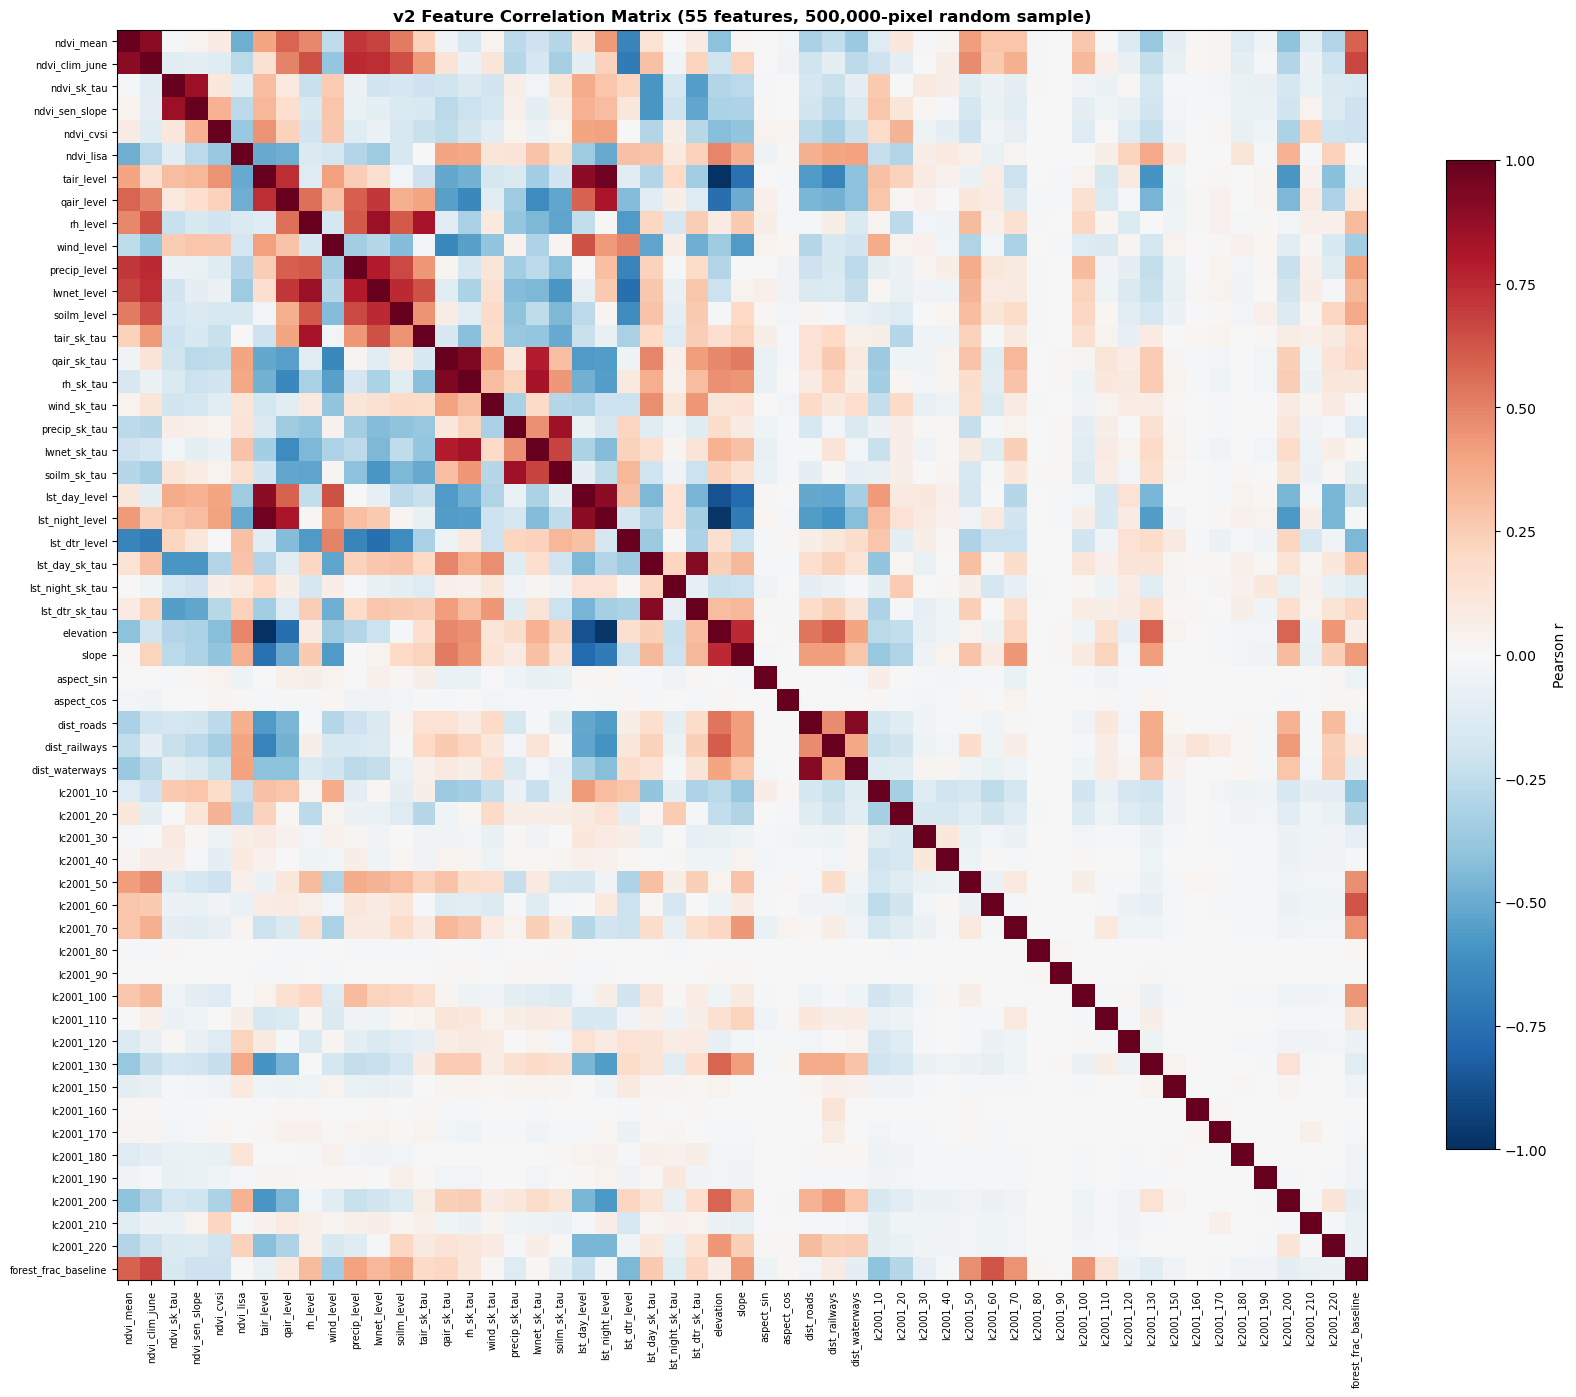

   Feature pairs with |r| > 0.9: 7
      tair_level             elevation              r = -0.985
      tair_level             lst_night_level        r = +0.974
      lst_night_level        elevation              r = -0.972
      qair_sk_tau            rh_sk_tau              r = +0.936
      lst_day_sk_tau         lst_dtr_sk_tau         r = +0.920
      dist_roads             dist_waterways         r = +0.911
      ndvi_mean              ndvi_clim_june         r = +0.904


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Fire_vs_NoFire_Feature_Distributions.png


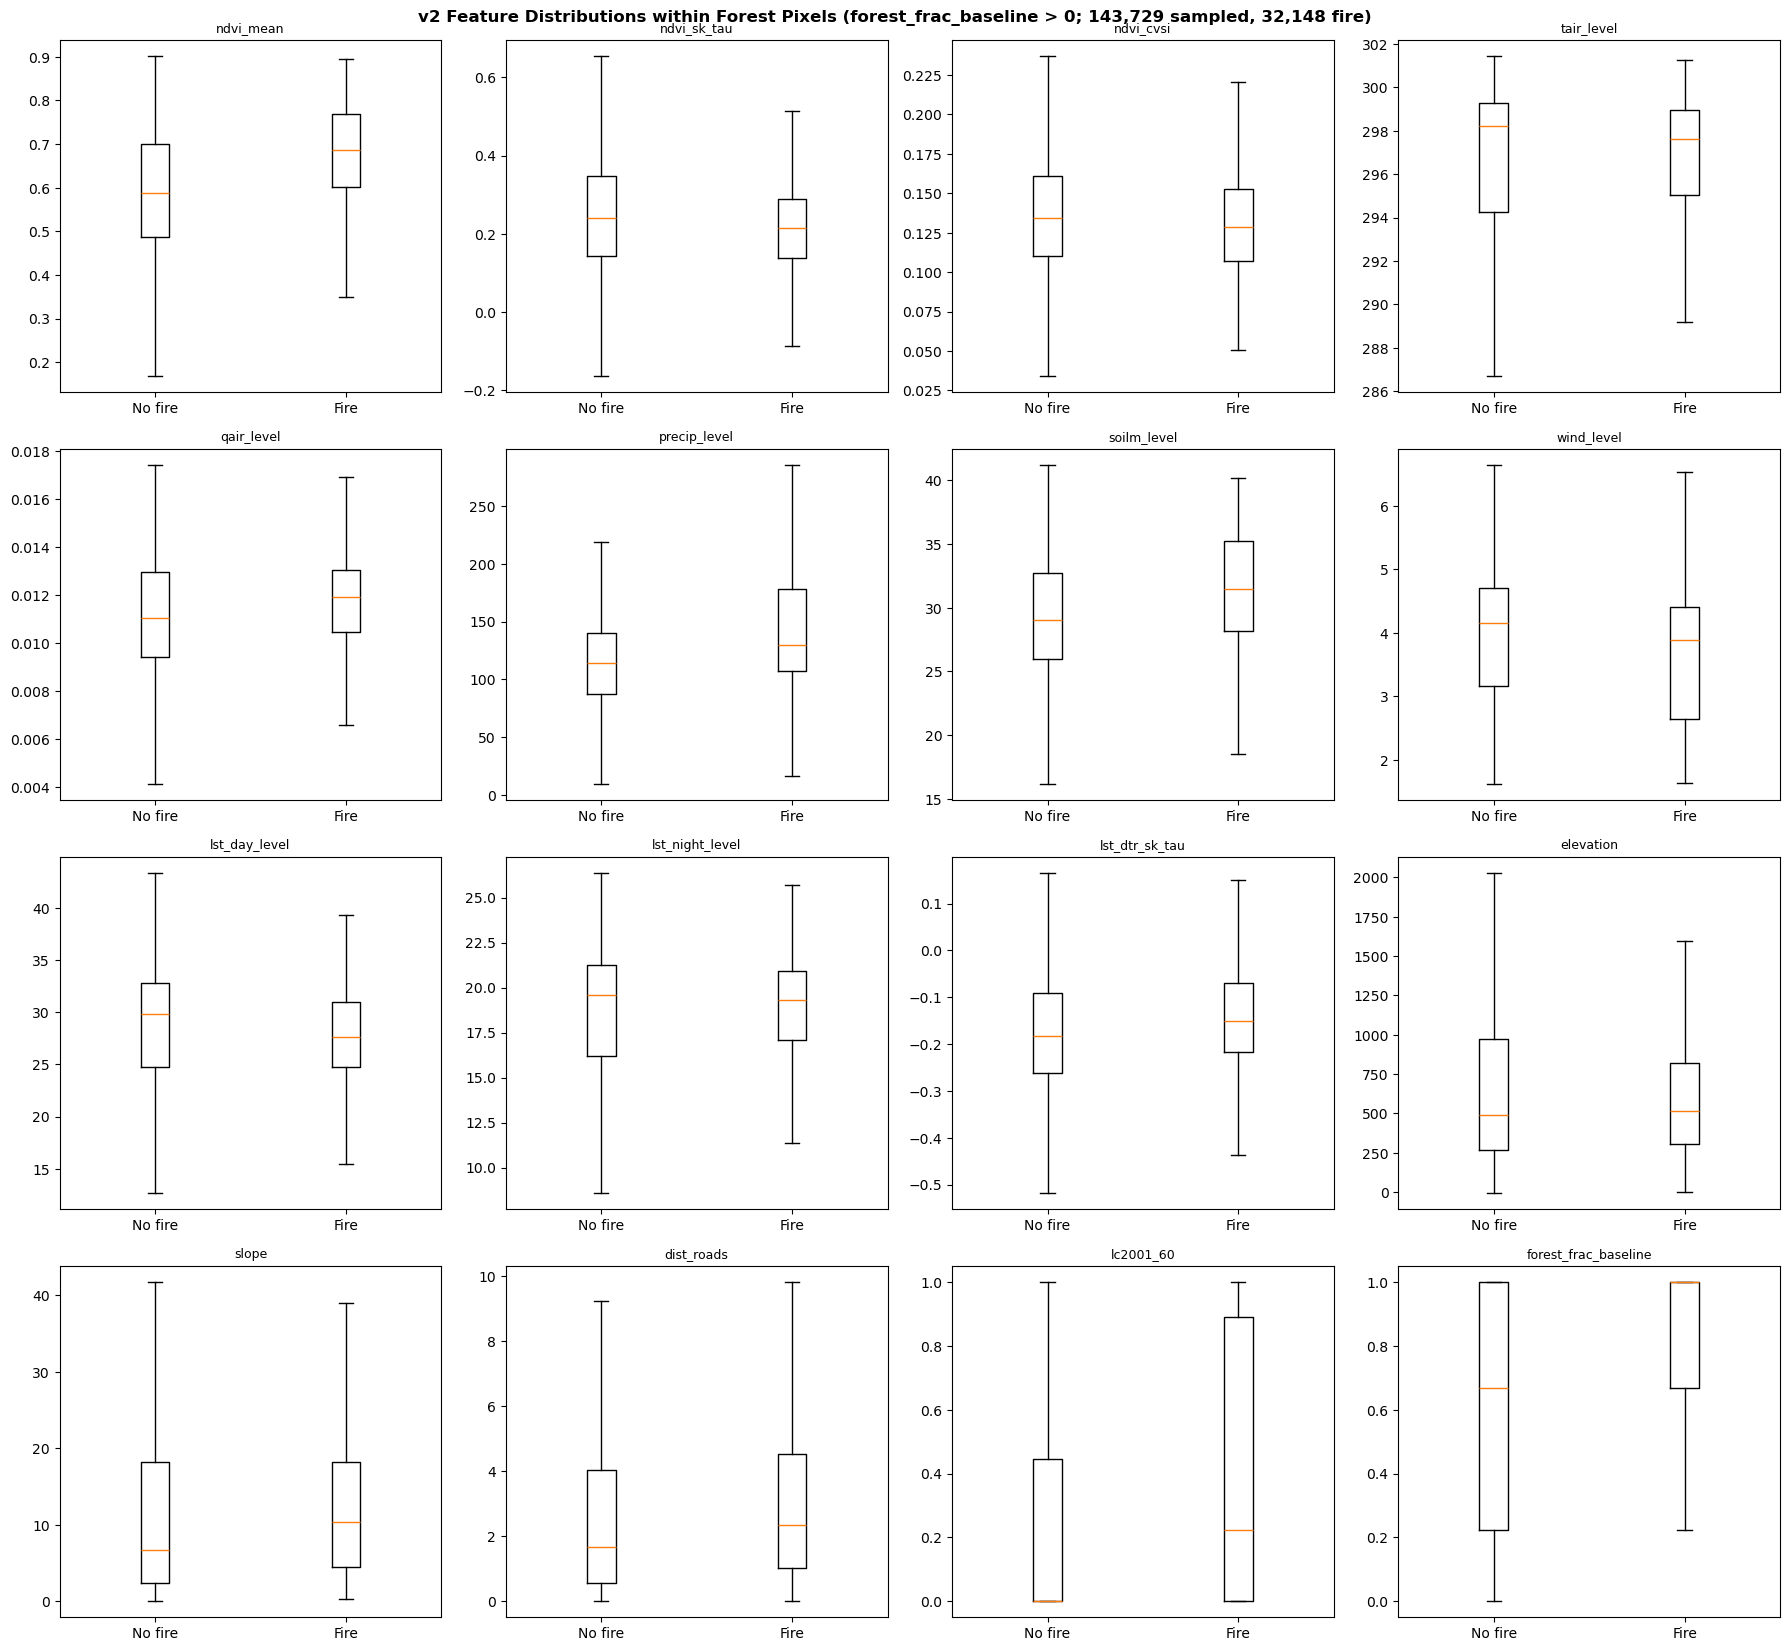


Visualizations complete


In [14]:
print("Generating correlation heatmap and fire-vs-non-fire comparison (v2 features)...")

corr_sample = df_pixels.sample(min(500_000, len(df_pixels)), random_state=42)
corr = corr_sample[feature_names].corr()

fig, ax = plt.subplots(figsize=(17, 15))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_names))); ax.set_xticklabels(feature_names, rotation=90, fontsize=7)
ax.set_yticks(range(len(feature_names))); ax.set_yticklabels(feature_names, fontsize=7)
plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.7)
ax.set_title(f'v2 Feature Correlation Matrix ({len(feature_names)} features, '
             f'{len(corr_sample):,}-pixel random sample)', fontweight='bold')
plt.tight_layout()
outfile = os.path.join(OUTPUT_DIR, 'Feature_Correlation_Matrix.png')
plt.savefig(outfile, dpi=150, bbox_inches='tight')
print(f"   Saved: {outfile}")
plt.show()

# Pairs with |r| > 0.9: redundancy worth noting in the methods (RF handles it, but importances are shared).
high = [(a, b, corr.loc[a, b]) for i, a in enumerate(feature_names) for b in feature_names[i + 1:]
        if abs(corr.loc[a, b]) > 0.9]
print(f"   Feature pairs with |r| > 0.9: {len(high)}")
for a, b, r in sorted(high, key=lambda t: -abs(t[2]))[:15]:
    print(f"      {a:<22} {b:<22} r = {r:+.3f}")

show_cols = [c for c in ['ndvi_mean', 'ndvi_sk_tau', 'ndvi_cvsi', 'tair_level', 'qair_level', 'precip_level',
                         'soilm_level', 'wind_level', 'lst_day_level', 'lst_night_level', 'lst_dtr_sk_tau',
                         'elevation', 'slope', 'dist_roads', 'lc2001_60', 'forest_frac_baseline']
             if c in feature_names]
forest_df = corr_sample[corr_sample['forest_frac_baseline'] > 0]
fire_mask_px = forest_df['fire_ever'] > 0
n_rows_fig = (len(show_cols) + 3) // 4
fig2, axes2 = plt.subplots(n_rows_fig, 4, figsize=(18, 4.2 * n_rows_fig))
for ax, col in zip(np.asarray(axes2).flat, show_cols):
    data_fire = forest_df.loc[fire_mask_px, col].dropna()
    data_nofire = forest_df.loc[~fire_mask_px, col].dropna()
    ax.boxplot([data_nofire, data_fire], tick_labels=['No fire', 'Fire'], showfliers=False)
    ax.set_title(col, fontsize=9)
for ax in np.asarray(axes2).flat[len(show_cols):]:
    ax.axis('off')
plt.suptitle(f'v2 Feature Distributions within Forest Pixels (forest_frac_baseline > 0; '
             f'{len(forest_df):,} sampled, {int(fire_mask_px.sum()):,} fire)', fontweight='bold')
plt.tight_layout()
outfile2 = os.path.join(OUTPUT_DIR, 'Fire_vs_NoFire_Feature_Distributions.png')
plt.savefig(outfile2, dpi=150, bbox_inches='tight')
print(f"   Saved: {outfile2}")
plt.show()

del corr_sample, forest_df
print("\nVisualizations complete")

## Step 6 Complete — v2 Table Summary

**Outputs** (in `Integrated_Analysis/Integrated_Outputs/`):

| File | Contents |
|---|---|
| `Integrated_FireRisk_Pixels.parquet` | One row per analysis pixel (India mask ∩ finite `ndvi_mean`; audit target 4,160,768), **row-major by `grid_index`**. 60 columns: `lon, lat, grid_index, fire_count, fire_ever` + 55 features |
| `FEATURE_LIST_v2.json` | Ordered feature names, groups, source file/band per feature, population, label, row order, run counts, removed v1 columns |
| `Integrated_FireRisk_Stack.tif` | 55 bands (one per feature, same order, band description = name), NaN outside the analysis population |
| `V2_vs_audit_reference_check.csv` | Column-by-column agreement with `results/recalculated/FEATURE_TABLE_v2.parquet` (when present) |
| `Integrated_FireRisk_Pixels_sample200k.csv` | 200k-row random sample of the table, for tools without parquet support |
| `Integrated_Monthly_TimeSeries.csv` | National-mean NDVI + LST + FLDAS + fire counts on `(year, month)` (diagnostic) |
| `Feature_Correlation_Matrix.png`, `Fire_vs_NoFire_Feature_Distributions.png` | Visual checks on the v2 columns (distributions within forest pixels) |

**Column provenance** (every source file is also recorded in `FEATURE_LIST_v2.json`):

| Columns | n | Source |
|---|---:|---|
| `lon`, `lat`, `grid_index` | – | NDVI grid (pixel centres; `grid_index = row*W + col`) |
| `fire_count`, `fire_ever` | – (labels) | Step 1 CSV → Step 2 `F10_fire_count_Step1.tif`, containing-pixel rule, checked against Step 1's CSV in this notebook |
| `ndvi_mean`, `ndvi_clim_june`, `ndvi_sk_tau`, `ndvi_sen_slope`, `ndvi_cvsi`, `ndvi_lisa` | 6 | Step 2: F1, F2, F6 Seasonal-Kendall τ / Sen slope, F7 CVSI(k\*), F8 LISA |
| `{tair,qair,rh,wind,precip,lwnet,soilm}_level` | 7 | Step 4: `{Var}_level_on_NDVI_grid.tif` (2001–2020 climatological annual mean) |
| `{tair,qair,rh,wind,precip,lwnet,soilm}_sk_tau` | 7 | Step 4: `SeasonalKendall_tau_{Var}_on_NDVI_grid.tif` |
| `lst_{day,night,dtr}_level`, `lst_{day,night,dtr}_sk_tau` | 6 | Step 3: `{LST_Day,LST_Night,DTR}_level_on_NDVI_grid.tif`, `SeasonalKendall_tau_*_on_NDVI_grid.tif` |
| `elevation`, `slope`, `aspect_sin`, `aspect_cos` | 4 | Step 5a: T1, T2, T3 (aspect → sin/cos of radians; NaN where flat) |
| `dist_roads`, `dist_railways`, `dist_waterways` | 3 | Step 5b: D1, D2, D3 |
| `lc2001_{10..220}` except 140 | 21 | Step 4: `LandCover_22Class_Fractions_2001.tif` (LC140 constant over India, dropped) |
| `forest_frac_baseline` | 1 | This notebook: ESA-CCI/C3S 2001, 13 LCCS forest codes, area average onto the NDVI grid |
| **Total features** | **55** | |

**Relation to v1** (the 57-feature table used before the audit). Removed: every anomaly mean
(NDVI, LST, 7 FLDAS), every Mann–Kendall τ, `ndvi_trend_2x12ma`, `ndvi_residual_mean`,
`ndvi_below_threshold`, the 22 **2020** land-cover fractions, and aspect in degrees. The label
changed from the half-pixel-shifted rasterisation to the containing-pixel one. The full list is
under `removed_from_v1` in `FEATURE_LIST_v2.json`, and the reasons are in the leakage table in
the LULC section above. Earlier notes describing v1 (2026-08-20 terrain wiring, 2026-08-21
forest-fraction leakage fix, 2026-08-22 specific humidity) are superseded by the audit. The
Biswas et al. (2025) 15-predictor parity still holds: every one of their 15 variables has a
level feature here (aspect as sin/cos).

**Audit targets** (`results/recalculated/FEATURE_TABLE_v2_report.json`): 4,160,768 pixels;
268,411 fire pixels (prevalence 0.0645); forest population (`forest_frac_baseline > 0`)
1,197,538 pixels, prevalence 0.2232. The assembly cell prints this run's values next to them.

**For Step 7:** read the parquet as-is. Keep the row order. Rebuild the 65/15/20 split with
`train_test_split(test_size=0.20, stratify=fire_ever, random_state=42)` and then
`train_test_split(test_size=0.15/0.80, stratify=..., random_state=42)` on the training part,
which is the audit's split. Fit any imputation on training rows only. Report both the all-pixel
and the forest-pixel population, with forest as primary. Paper numbers come only from
`results/FINAL_MANUSCRIPT_NUMBERS.md`; the methodology is in `results/FULL_METHODOLOGY_AUDIT.md`.

**Adding a source later:** add a named loading block that uses `load_feature()` (warn and skip
on a missing file, with a hard grid check), add its name to `FEATURE_GROUPS_V2` in the assembly
cell, and update the provenance table above and `Integrated_Analysis/README.md`.